Dane: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [ ]:
#!/bin/bash
!kaggle datasets download mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
 88% 58.0M/66.0M [00:00<00:00, 106MB/s] 
100% 66.0M/66.0M [00:00<00:00, 107MB/s]


In [ ]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('creditcard.csv')

In [ ]:
df.shape

(284807, 31)

In [ ]:
from matplotlib import pyplot as plt

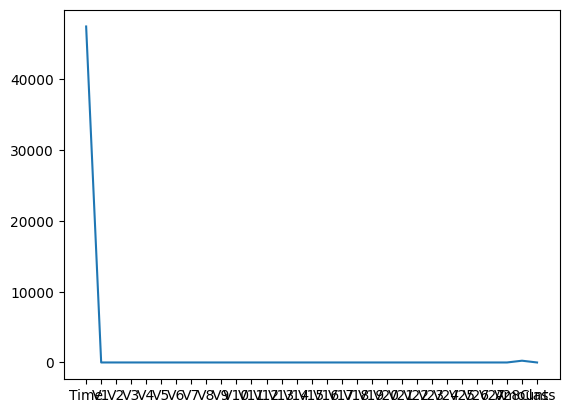

In [ ]:
plt.plot(df.describe().T['std'])

# Zadanie: policzyć korelacje i pokazyć wykres dla korelacji (heatmap)

In [ ]:
import seaborn as sns

<Axes: >

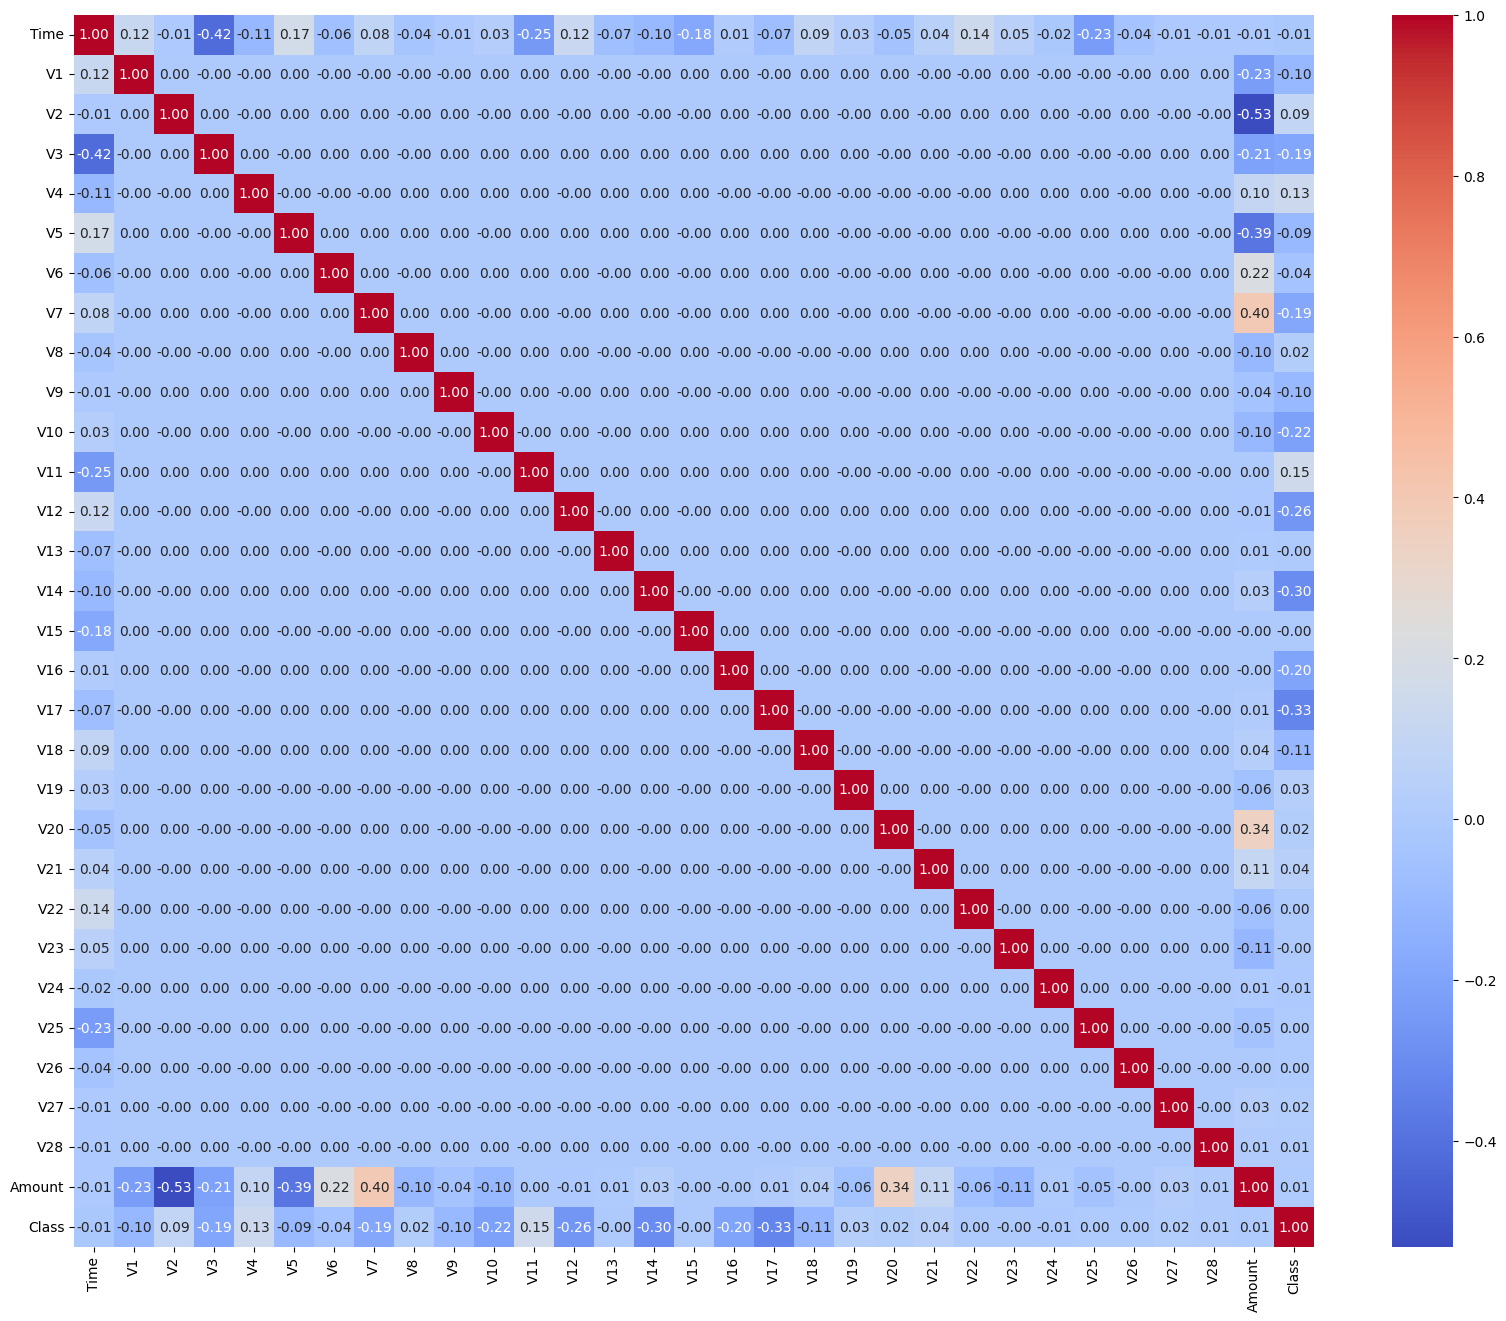

In [ ]:
plt.figure(figsize=(20,16))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class'].astype(str)

In [ ]:
clf.fit(X, y)

DecisionTreeClassifier()

In [ ]:
dot_data = export_graphviz(
    clf,
    out_file=None,
    class_names=clf.classes_,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    special_characters=True
    )

In [ ]:
graph = graphviz.Source(dot_data)

In [ ]:
clf.score(X, y)

1.0

# Teraz podziale na zbiór treningowy i testowy

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
clf_2 = DecisionTreeClassifier(random_state=456)
clf_2.fit(X_train, y_train)
clf_2.score(X_train, y_train)
clf_2.score(X_test, y_test)
y_pred = clf_2.predict(X_test)
dot_data_2 = export_graphviz(
    clf_2,
    out_file=None,
    class_names=clf_2.classes_,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    special_characters=True
    )
graph = graphviz.Source(dot_data_2)

In [ ]:
clf_2.score(X_train, y_train), clf_2.score(X_test, y_test)

(1.0, 0.9992860737567735)

## Model -1

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
(284315)/(len(df))

0.9982725143693799

In [ ]:
0.9992860737567735 - 0.9982725143693799

0.0010135593873935589

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
y_tr_pred = clf_2.predict(X_train)
confusion_matrix(y_train, y_tr_pred)

array([[199019,      0],
       [     0,    345]])

In [ ]:
y_ts_pred = clf_2.predict(X_test)
confusion_matrix(y_test, y_ts_pred)

array([[85272,    24],
       [   37,   110]])

Ręcznie obliczenia w excel:  
 https://docs.google.com/spreadsheets/d/1t_ZgcNIuAMLFev3tyHjpYs1kViYqD8HVBUm8rKF-LZw/edit?gid=0#gid=0

 Wikipedia:  
 https://en.wikipedia.org/wiki/Sensitivity_and_specificity
  

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_train, y_tr_pred))

In [ ]:
print(classification_report(y_test, y_ts_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85296
           1       0.82      0.75      0.78       147

    accuracy                           1.00     85443
   macro avg       0.91      0.87      0.89     85443
weighted avg       1.00      1.00      1.00     85443



# Random forest  
https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier

In [ ]:
from sklearn import ensemble

In [ ]:
rfc = ensemble.RandomForestClassifier(n_estimators=100)

In [ ]:
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
rfc.score(X_train, y_train), rfc.score(X_test, y_test)

(1.0, 0.9995084442259752)

In [ ]:
print(classification_report(y_test, rfc.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85296
           1       0.94      0.76      0.84       147

    accuracy                           1.00     85443
   macro avg       0.97      0.88      0.92     85443
weighted avg       1.00      1.00      1.00     85443



In [ ]:
confusion_matrix(y_test, rfc.predict(X_test))

array([[85289,     7],
       [   35,   112]])